# Tasks

## P 7.1: Download the adult_T7 dataset from Canvas. Use four classifiers to predict the 'income' column. Calculate all evaluation metrics using a five-fold cross-validation. Print the feature importance values from the random forest classifier. You should improve your models as best as you can (10%).

In [1]:
############# WRITE YOUR CODE IN THIS CELL (IF APPLICABLE)  ####################

import pandas as pd
import numpy as np
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt


In [3]:
data = pd.read_csv('https://raw.githubusercontent.com/ifeanyianyanwu/ai-and-ml/refs/heads/main/adult_T7.csv')
data.head(10)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,29,Private,216481,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,>50K
1,36,Private,280570,Some-college,10,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,45,United-States,<=50K
2,25,?,100903,Bachelors,13,Married-civ-spouse,?,Wife,White,Female,0,0,25,United-States,<=50K
3,47,Private,145636,Assoc-voc,11,Married-civ-spouse,Handlers-cleaners,Husband,White,Male,0,0,48,United-States,>50K
4,33,Private,119422,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States,<=50K
5,37,Private,186808,HS-grad,9,Never-married,Sales,Unmarried,White,Male,0,0,40,United-States,<=50K
6,34,Private,339142,HS-grad,9,Separated,Handlers-cleaners,Unmarried,White,Female,0,0,40,United-States,<=50K
7,38,Private,101387,HS-grad,9,Married-civ-spouse,Other-service,Wife,White,Female,0,0,43,United-States,<=50K
8,62,Private,166691,HS-grad,9,Divorced,Exec-managerial,Unmarried,White,Female,0,0,40,United-States,<=50K
9,50,Local-gov,50178,Some-college,10,Married-civ-spouse,Craft-repair,Husband,White,Male,4064,0,55,United-States,<=50K


In [4]:
# Separate features and target
X = data.drop('income', axis=1)
y = data['income']

In [8]:
# Preprocessing: Encode categorical variables and scale numerical ones
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(exclude=['object']).columns

In [9]:
#  Transformers
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))])

In [10]:
# Combined transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)])

In [11]:
# Encode target variable
y = LabelEncoder().fit_transform(y)

In [12]:
# Define models with improved parameters
models = {
    'SVM': SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, min_samples_split=5, random_state=42)
}

In [13]:
# Define metrics for cross-validation
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
    'f1': make_scorer(f1_score)
}

In [14]:
# Perform 5-fold cross-validation for each model
results = {}
for name, model in models.items():
    # Create full pipeline
    clf = Pipeline(steps=[('preprocessor', preprocessor),
                         ('classifier', model)])

    cv_results = cross_validate(clf, X, y, cv=5, scoring=scoring)
    results[name] = {
        'accuracy': cv_results['test_accuracy'].mean(),
        'precision': cv_results['test_precision'].mean(),
        'recall': cv_results['test_recall'].mean(),
        'f1': cv_results['test_f1'].mean()
    }

In [15]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
X_processed = preprocessor.fit_transform(X)
rf.fit(X_processed, y)

RandomForestClassifier(random_state=42)

In [16]:
cat_features = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_cols)
all_features = np.concatenate([numerical_cols, cat_features])

In [17]:
feature_importances = pd.DataFrame({
    'feature': all_features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nRandom Forest Feature Importances (Top 10):")
print(feature_importances.head(10))


Random Forest Feature Importances (Top 10):
                              feature  importance
0                                 age    0.143493
1                              fnlwgt    0.140493
3                        capital-gain    0.086322
5                      hours-per-week    0.083360
33  marital-status_Married-civ-spouse    0.065515
2                       education-num    0.059642
53               relationship_Husband    0.035537
35       marital-status_Never-married    0.032589
4                        capital-loss    0.031004
42         occupation_Exec-managerial    0.024172


## P 7.2: Use two clustering methods to cluster a numerical column in the dataset. Find the optimum number of clusters using the elbow method (5%).  

## NOTE: Please complete this task in the next week's workshop
## NOTE: You can use any aptional numerical column for this task.

In [18]:
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

In [19]:
df = data

In [20]:
# Handle missing values
df.replace("?", np.nan, inplace=True)
df.dropna(subset=["hours-per-week"], inplace=True)
df["hours-per-week"] = pd.to_numeric(df["hours-per-week"])

In [21]:
X = df[["hours-per-week"]].values

In [22]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [23]:
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

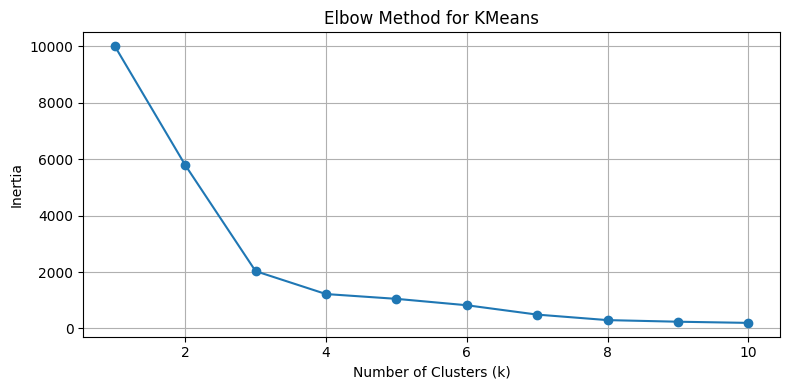

In [24]:
plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o')
plt.title("Elbow Method for KMeans")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.grid(True)
plt.tight_layout()
plt.show()

In [25]:
optimal_k = 3

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42)
df["KMeans_Cluster"] = kmeans_final.fit_predict(X_scaled)

agglo = AgglomerativeClustering(n_clusters=optimal_k)
df["Agglo_Cluster"] = agglo.fit_predict(X_scaled)

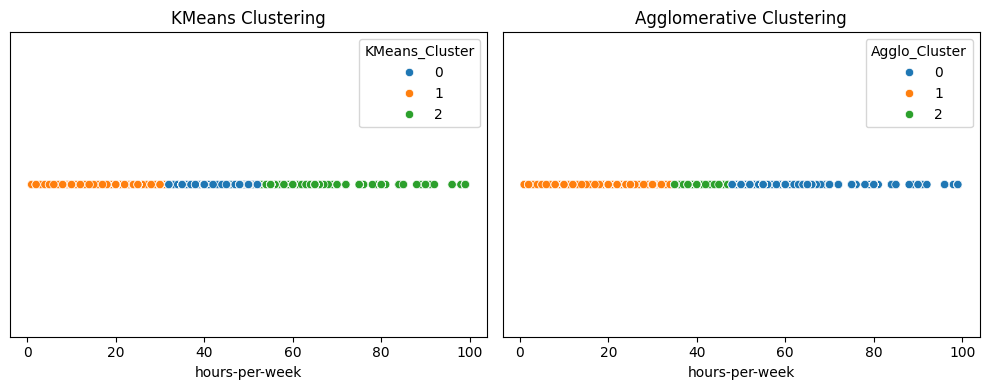

In [26]:
# Visualize the clusters
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.scatterplot(x="hours-per-week", y=[0]*len(df), hue="KMeans_Cluster", data=df, palette="tab10")
plt.title("KMeans Clustering")
plt.yticks([])

plt.subplot(1, 2, 2)
sns.scatterplot(x="hours-per-week", y=[0]*len(df), hue="Agglo_Cluster", data=df, palette="tab10")
plt.title("Agglomerative Clustering")
plt.yticks([])

plt.tight_layout()
plt.show()